In [1018]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt 
import plotly_express as px 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [1019]:
data = yf.download("AAPL", start='2020-01-01', end='2026-04-18')

[*********************100%***********************]  1 of 1 completed


In [1020]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200


In [1021]:
data.columns = data.columns.droplevel(1)

In [1022]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1581 entries, 2020-01-02 to 2026-04-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1581 non-null   float64
 1   High    1581 non-null   float64
 2   Low     1581 non-null   float64
 3   Open    1581 non-null   float64
 4   Volume  1581 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 74.1 KB


In [1023]:
# Calculating Price Change
data['Price_Change'] = data['Close'].diff()
data['pct_change'] = data['Close'].pct_change() * 100
data.dropna(inplace=True)
data.head(5)

Price,Close,High,Low,Open,Volume,Price_Change,pct_change
Date,,,,,,,
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800,-0.703880,-0.972204
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200,0.571312,0.796846
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000,-0.339874,-0.470297
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200,1.157036,1.608601
2020-01-09,74.637489,74.830329,73.810677,74.061367,170108400,1.552391,2.124087


In [1024]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Price_Change', 'pct_change'], dtype='object', name='Price')

In [1025]:
# Seprating Gain and loss
data["Gain"] = data["Price_Change"].clip(lower=0)
data["Loss"] = -data["Price_Change"].clip(upper=0)

In [1026]:
# Rolling Average
data['Avg_Gain'] = data['Gain'].rolling(5).mean()
data['Avg_Loss'] = data['Loss'].rolling(5).mean()

In [1027]:
# Moving Average
data['MA_10'] = data['Close'].rolling(10).mean()
data['MA_50'] = data['Close'].rolling(50).mean()
data['MA_20'] = data['Close'].rolling(20).mean()
data['MA_100'] = data['Close'].rolling(100).mean()

data['MA_ratio'] = data['MA_10'] / data['MA_50']

# Volatility
data['Volatility'] = data['Close'].rolling(10).std()

In [1028]:
data['Momentum'] = data['Close'] - data['Close'].shift(5)
data['Momentum_10'] = data['Close'] - data['Close'].shift(10)
data['ROC'] = data['Close'].pct_change(periods=10)
data['EMA_10'] = data['Close'].ewm(span=10).mean()

In [1029]:
data['BB_Middle'] = data['Close'].rolling(20).mean()
data['BB_Std'] = data['Close'].rolling(20).std()

data['BB_Upper'] = data['BB_Middle'] + 2 * data['BB_Std']
data['BB_Lower'] = data['BB_Middle'] - 2 * data['BB_Std']

data['BB_Width'] = data['BB_Upper'] - data['BB_Lower']

In [1030]:
ema12 = data['Close'].ewm(span=12).mean()
ema26 = data['Close'].ewm(span=26).mean()
data['MACD'] = ema12 - ema26

In [1031]:
data['Volume_MA_10'] = data['Volume'].rolling(10).mean()
data['Volume_Ratio'] = data['Volume'] / data['Volume_MA_10']

In [1032]:
data['Volume_Change'] = data['Volume'].pct_change()

In [1033]:
# Relative Strength
data['RS'] = data['Avg_Gain'] / data['Avg_Loss']

In [1034]:
# RSI 
data['RSI'] = 100 - (100/(1 + data['RS']))

In [1035]:
data['RSI_Lag1'] = data['RSI'].shift(1)
data['RSI_Lag2'] = data['RSI'].shift(2)

data['Return_Lag1'] = data['pct_change'].shift(1)
data['Return_Lag2'] = data['pct_change'].shift(2)

In [1036]:
# Signal
data["Signal"] = "HOLD"
data.loc[(data["RSI"] < 30) & (data["RSI"].shift(1) >= 30), "Signal"] = "BUY"
data.loc[(data["RSI"] > 70) & (data["RSI"].shift(1) <= 70), "Signal"] = "SELL"

In [1037]:
data.dropna(inplace=True)

In [1038]:
data.head(21)

Price,Close,High,Low,Open,Volume,Price_Change,pct_change,Gain,Loss,Avg_Gain,...,Volume_MA_10,Volume_Ratio,Volume_Change,RS,RSI,RSI_Lag1,RSI_Lag2,Return_Lag1,Return_Lag2,Signal
Date,,,,,,,,,,,,,,,,,,,,,
2020-05-27,77.071663,77.217032,75.855420,76.594379,112945200,0.334312,0.435658,0.334312,-0.000000,0.460815,...,129727200.0,0.870636,-0.100196,2.094662,67.686294,56.107764,78.549568,-0.677367,0.643873,HOLD
2020-05-28,77.105606,78.363040,76.470834,76.747029,133560800,0.033943,0.044041,0.033943,-0.000000,0.172507,...,123021040.0,1.085674,0.182527,0.784139,43.950550,67.686294,56.107764,0.435658,-0.677367,HOLD
2020-05-29,77.030495,77.808211,76.674343,77.347881,153532400,-0.075111,-0.097414,0.000000,0.075111,0.172507,...,122481360.0,1.253516,0.149532,1.441280,59.037881,43.950550,67.686294,0.044041,0.435658,HOLD
2020-06-01,77.977814,78.098954,76.853631,76.984464,80791200,0.947319,1.229797,0.947319,-0.000000,0.263115,...,113925640.0,0.709157,-0.473784,2.198304,68.733433,59.037881,43.950550,-0.097414,0.044041,HOLD
2020-06-02,78.338806,78.363036,77.270351,77.711302,87642800,0.360992,0.462942,0.360992,-0.000000,0.335313,...,109172080.0,0.802795,0.084806,22.321077,95.712033,68.733433,59.037881,1.229797,-0.097414,SELL
2020-06-03,78.770073,79.031739,78.086842,78.658626,104491200,0.431267,0.550515,0.431267,-0.000000,0.354704,...,109448240.0,0.954709,0.192239,23.611884,95.936922,95.712033,68.733433,0.462942,1.229797,HOLD
2020-06-04,78.091690,78.891211,77.718577,78.593211,87560400,-0.678383,-0.861219,0.000000,0.678383,0.347916,...,107053800.0,0.817910,-0.162031,2.308681,69.776480,95.936922,95.712033,0.550515,0.462942,HOLD
2020-06-05,80.315811,80.376381,78.312158,78.341231,137250400,2.224121,2.848089,2.224121,-0.000000,0.792740,...,110509960.0,1.241973,0.567494,5.842865,85.386237,69.776480,95.936922,-0.861219,0.550515,SELL
2020-06-08,80.790672,80.824595,79.303077,80.012956,95654400,0.474861,0.591242,0.474861,-0.000000,0.698248,...,111895080.0,0.854858,-0.303067,5.146417,83.730360,85.386237,69.776480,2.848089,-0.861219,HOLD


In [1039]:
data.isnull().sum()

Price
Close            0
High             0
Low              0
Open             0
Volume           0
Price_Change     0
pct_change       0
Gain             0
Loss             0
Avg_Gain         0
Avg_Loss         0
MA_10            0
MA_50            0
MA_20            0
MA_100           0
MA_ratio         0
Volatility       0
Momentum         0
Momentum_10      0
ROC              0
EMA_10           0
BB_Middle        0
BB_Std           0
BB_Upper         0
BB_Lower         0
BB_Width         0
MACD             0
Volume_MA_10     0
Volume_Ratio     0
Volume_Change    0
RS               0
RSI              0
RSI_Lag1         0
RSI_Lag2         0
Return_Lag1      0
Return_Lag2      0
Signal           0
dtype: int64

In [1040]:
data['Future_Return'] = (data['Close'].shift(-3) - data['Close']) / data['Close']

data['Target'] = np.where(data['Future_Return'] > 0.03, "BUY",
                   np.where(data['Future_Return'] < -0.03, "SELL", "HOLD"))

In [1041]:
le = LabelEncoder()
Y = le.fit_transform(data["Target"])

In [1042]:
# features = ["RSI", "Avg_Gain", "Avg_Loss", "Price_Change", "pct_change","Volatility","MA_10","MA_50","Volume_Change","MACD","EMA_10","Momentum"]
features = ["BB_Width","MA_ratio","Volatility","MA_10","MA_100","MACD","RSI_Lag2","Return_Lag1","Volume_Ratio","Return_Lag2","Volume_Change","MA_50","Avg_Gain"]
X = data[features]
Y = data["Target"]

In [1043]:
# # Train test Split 
# split = int(len(data)*0.8)

# X_train = X[:split]
# X_test = X[split:]

# Y_train = Y[:split]
# Y_test = Y[split:]

In [1044]:
tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]

In [1045]:

train_index = X_train.index
test_index = X_test.index

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train = pd.DataFrame(X_train, index=train_index, columns=features)
X_test = pd.DataFrame(X_test, index=test_index, columns=features)

In [1046]:
# LogisticRegression 
model_lr = LogisticRegression()
model_lr.fit(X_train,Y_train)

# Prediction
y_pred_lr = model_lr.predict(X_test)

# Accuracy Check
print('Accuracy :', accuracy_score(Y_test,y_pred_lr))
print('classification_report:',classification_report(Y_test,y_pred_lr))

result = pd.DataFrame({
    'Actual': Y_test,
    'Prediction': y_pred_lr
})
result.head()

Accuracy : 0.7560975609756098
classification_report:               precision    recall  f1-score   support

         BUY       0.00      0.00      0.00        35
        HOLD       0.76      1.00      0.86       186
        SELL       0.00      0.00      0.00        25

    accuracy                           0.76       246
   macro avg       0.25      0.33      0.29       246
weighted avg       0.57      0.76      0.65       246



C:\Users\Shubham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Shubham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Shubham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics

,Actual,Prediction
Date,,
2025-04-25,HOLD,HOLD
2025-04-28,HOLD,HOLD
2025-04-29,HOLD,HOLD
2025-04-30,SELL,HOLD
2025-05-01,SELL,HOLD


In [1047]:
# RandomForestClassifier
model_rf = RandomForestClassifier()
model_rf.fit(X_train,Y_train)

#Prediction
y_pred_rf = model_rf.predict(X_test)

#Accuracy check
print('accuracy_score :', accuracy_score(Y_test,y_pred_rf))
print('classification_report:',classification_report(Y_test,y_pred_rf))


#Prediction check
result_rf = pd.DataFrame({
    'Actual':Y_test,
    'Predicted':y_pred_rf
})
result_rf.head()

accuracy_score : 0.47560975609756095
classification_report:               precision    recall  f1-score   support

         BUY       1.00      0.03      0.06        35
        HOLD       0.75      0.56      0.64       186
        SELL       0.11      0.48      0.18        25

    accuracy                           0.48       246
   macro avg       0.62      0.36      0.29       246
weighted avg       0.72      0.48      0.51       246



,Actual,Predicted
Date,,
2025-04-25,HOLD,HOLD
2025-04-28,HOLD,HOLD
2025-04-29,HOLD,HOLD
2025-04-30,SELL,HOLD
2025-05-01,SELL,HOLD


In [1048]:
# XGBClassifier
le = LabelEncoder()
Y_train = le.fit_transform(Y_train)
Y_test = le.transform(Y_test)
model_XG = XGBClassifier(
    # n_estimators=500,
    # max_depth=5,
    # learning_rate=0.03,
    # subsample=0.8,
    # colsample_bytree=0.8,
    # objective='multi:softprob',
    # num_class=3,
    # eval_metric='mlogloss'
)
model_XG.fit(X_train,Y_train)

y_pred_xg = model_XG.predict(X_test)

print('Accuracy :',accuracy_score(Y_test,y_pred_xg))
print('classification_report:',classification_report(Y_test,y_pred_xg))


result_xg = pd.DataFrame({
    'Actual':Y_test,
    'Prediction':y_pred_xg
})
result_xg.head()


Accuracy : 0.7073170731707317
classification_report:               precision    recall  f1-score   support

           0       0.50      0.09      0.15        35
           1       0.77      0.91      0.84       186
           2       0.05      0.04      0.04        25

    accuracy                           0.71       246
   macro avg       0.44      0.35      0.34       246
weighted avg       0.66      0.71      0.66       246



,Actual,Prediction
0,1,1
1,1,1
2,1,1
3,2,1
4,2,1


In [1049]:
print("Train:", model_XG.score(X_train, Y_train))
print("Test:", model_XG.score(X_test, Y_test))

Train: 1.0
Test: 0.7073170731707317


In [1050]:
data.head()

Price,Close,High,Low,Open,Volume,Price_Change,pct_change,Gain,Loss,Avg_Gain,...,Volume_Change,RS,RSI,RSI_Lag1,RSI_Lag2,Return_Lag1,Return_Lag2,Signal,Future_Return,Target
Date,,,,,,,,,,,,,,,,,,,,,
2020-05-27,77.071663,77.217032,75.855420,76.594379,112945200,0.334312,0.435658,0.334312,-0.000000,0.460815,...,-0.100196,2.094662,67.686294,56.107764,78.549568,-0.677367,0.643873,HOLD,0.011757,HOLD
2020-05-28,77.105606,78.363040,76.470834,76.747029,133560800,0.033943,0.044041,0.033943,-0.000000,0.172507,...,0.182527,0.784139,43.950550,67.686294,56.107764,0.435658,-0.677367,HOLD,0.015994,HOLD
2020-05-29,77.030495,77.808211,76.674343,77.347881,153532400,-0.075111,-0.097414,0.000000,0.075111,0.172507,...,0.149532,1.441280,59.037881,43.950550,67.686294,0.044041,0.435658,HOLD,0.022583,HOLD
2020-06-01,77.977814,78.098954,76.853631,76.984464,80791200,0.947319,1.229797,0.947319,-0.000000,0.263115,...,-0.473784,2.198304,68.733433,59.037881,43.950550,-0.097414,0.044041,HOLD,0.001460,HOLD
2020-06-02,78.338806,78.363036,77.270351,77.711302,87642800,0.360992,0.462942,0.360992,-0.000000,0.335313,...,0.084806,22.321077,95.712033,68.733433,59.037881,1.229797,-0.097414,SELL,0.025237,HOLD


In [1051]:
Y_test = pd.Series(Y_test, index=X_test.index)
X_test = pd.DataFrame(X_test, index=Y_test.index)

In [1052]:
y_pred_final = y_pred_xg
y_pred_final = le.inverse_transform(y_pred_final)

data.loc[X_test.index, 'ML_Signal'] = y_pred_final

In [1053]:
def final_signal(row):
    if row['Signal'] == 'BUY' and row['ML_Signal'] == 'BUY':
        return 'STRONG BUY'
    
    elif row['Signal'] == 'SELL' and row['ML_Signal'] == 'SELL':
        return 'STRONG SELL'
    
    elif row['ML_Signal'] == 'BUY':
        return 'WEAK BUY'
    
    elif row['ML_Signal'] == 'SELL':
        return 'WEAK SELL'
    
    else:
        return 'HOLD'
    
data['Final_Signal'] = data.apply(final_signal, axis = 1)

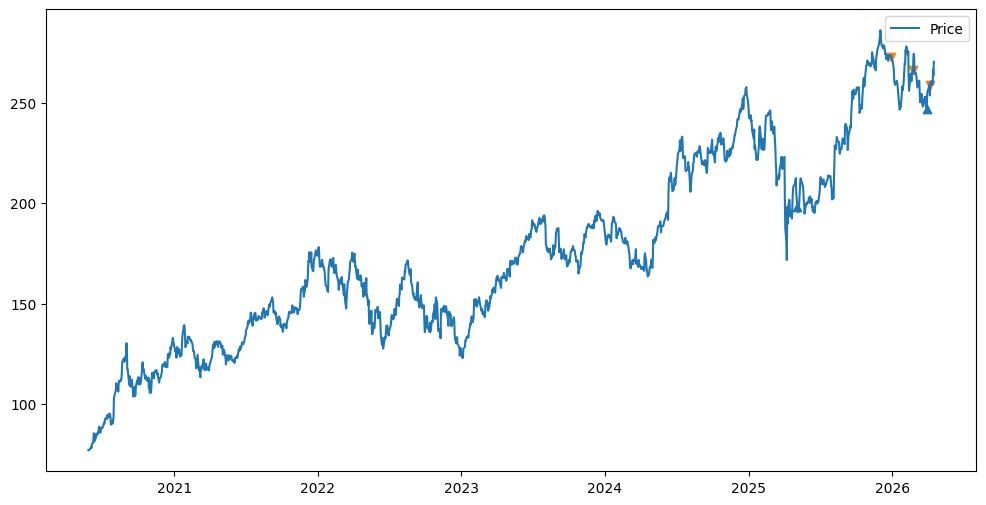

In [1054]:
buy = data[data['Final_Signal'] == 'STRONG BUY']
sell = data[data['Final_Signal'] == 'STRONG SELL']

plt.figure(figsize=(12,6))

plt.plot(data['Close'], label='Price')

plt.scatter(buy.index, buy['Close'], marker='^')
plt.scatter(sell.index, sell['Close'], marker='v')

plt.legend()
plt.show()

In [1055]:
buy = data[data['Final_Signal'] == 'STRONG BUY']
sell = data[data['Final_Signal'] == 'STRONG SELL']

fig = px.line(data, x=data.index, y='Close', title='Trading Signals')
fig.add_scatter(x=buy.index, y=buy['Close'], mode='markers', 
                marker=dict(symbol='triangle-up', size=10, color='green'), 
                name='STRONG BUY')
fig.add_scatter(x=sell.index, y=sell['Close'], mode='markers', 
                marker=dict(symbol='triangle-down', size=10, color='red'), 
                name='STRONG SELL')
fig.show()


In [1056]:
latest = data.iloc[-1]

print("Price:", latest['Close'])
print("RSI Signal:", latest['Signal'])
print("ML Signal:", latest['ML_Signal'])
print("Final Signal:", latest['Final_Signal'])

Price: 270.2300109863281
RSI Signal: SELL
ML Signal: HOLD
Final Signal: HOLD


In [1057]:
#confidance score
confidence = 0

if latest['Signal'] == latest['ML_Signal']:
    confidence = 2
elif latest['ML_Signal'] != 'HOLD':
    confidence = 1
else:
    confidence = 0

print("Confidence:", confidence)

Confidence: 0


In [1058]:
# Decision Sytem 
if latest['Final_Signal'] == 'STRONG BUY':
    print("ENTER TRADE")
elif latest['Final_Signal'] == 'STRONG SELL':
    print("EXIT")
else:
    print("WAIT")

WAIT


In [1059]:
## Variables
capital = 10000
position = 0
buy_price = 0

stop_loss = 0.03
take_profit = 0.06

trades = []

for i in range(len(data)):

    signal = data['Final_Signal'].iloc[i]
    price = data['Close'].iloc[i]

    #  Trend filter
    trend = "UP" if data['MA_50'].iloc[i] > data['MA_100'].iloc[i] else "DOWN"

    #  BUY 
    if signal in ['STRONG BUY', 'WEAK BUY'] and position == 0 and trend == "UP":
        position = capital / price
        buy_price = price
        capital = 0
        trades.append(('BUY', price, data.index[i]))

    #  SELL 
    elif signal in ['STRONG SELL', 'WEAK SELL'] and position != 0:
        capital = position * price
        position = 0
        trades.append(('SELL', price, data.index[i]))

    # RISK MANAGEMENT 
    elif position != 0:

        # Stop Loss
        if price < buy_price * (1 - stop_loss):
            capital = position * price
            position = 0
            trades.append(('STOP LOSS', price, data.index[i]))

        # Take Profit
        elif price > buy_price * (1 + take_profit):
            capital = position * price
            position = 0
            trades.append(('TAKE PROFIT', price, data.index[i]))


# IMPORTANT: close last position
if position != 0:
    capital = position * data['Close'].iloc[-1]
    trades.append(('FINAL SELL', data['Close'].iloc[-1], data.index[-1]))
    position = 0

In [1060]:
# calculating  value 
if position != 0:
    capital = position * data['Close'].iloc[-1]

print("Final Capital:", capital)

Final Capital: 10781.857808494908


In [1061]:
profit = capital - 10000
print("Profit:",profit)

Profit: 781.8578084949077


In [1062]:
# Buy pe
capital = capital * (1 - 0.001)

# Sell pe
capital = capital * (1 - 0.001)

In [1063]:
print("Total Trades:", len(trades)//2)

Total Trades: 1


In [1064]:
profits = []
wins = 0
total = 0

for i in range(0, len(trades)-1, 2):
    buy_price = trades[i][1]
    sell_price = trades[i+1][1]

    if sell_price > buy_price:
        wins += 1

    total += 1

print("Win Rate:", wins/total if total > 0 else 0)

Win Rate: 1.0


In [1065]:
returns = (capital - 10000) / 10000
print("Return %:", returns * 100)

Return %: 7.603048747357261


In [1066]:
data.to_json("dashboard.json", orient="records")

In [1067]:
data.to_csv("final_output.csv")

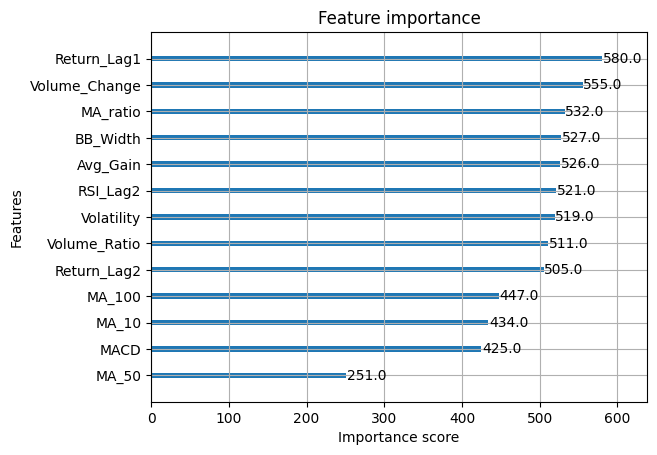

In [1068]:
plot_importance(model_XG)
plt.show()